# 📰 News Article Category Prediction

**Objective:** Build a machine learning pipeline to predict the primary category of a news article (lifestyle, entertainment, tech, business, world, social media) based on article statistics, word counts, and metadata using the **OnlineNewsPopularity** dataset.

This project will walk through:
1. **Data Loading & Cleaning**
2. **Exploratory Data Analysis (EDA)**
3. **Feature Selection & Preprocessing**
4. **Model Training & Comparison** (Random Forest, Logistic Regression, Fast Gradient Boosting)
5. **Insights & Visualizations**

--- 
## 1. Importing Libraries & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set theme for presentation
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 100, 'font.size': 12})

import warnings
warnings.filterwarnings('ignore')

print('All libraries successfully imported ✔️')

All libraries successfully imported ✔️


--- 
## 2. Loading the Dataset & Data Cleaning

In [2]:
# Load dataset
data = pd.read_csv('OnlineNewsPopularity/OnlineNewsPopularity.csv')

# Clean column names (strip trailing/leading spaces)
data.columns = data.columns.str.strip()

print(f"Dataset Shape: {data.shape[0]} rows × {data.shape[1]} columns")
data.head()

Dataset Shape: 39644 rows × 61 columns


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [3]:
print("Missing Values:\n", data.isnull().sum()[data.isnull().sum() > 0])
print("\n(No missing values found! 🎉)")

Missing Values:
 Series([], dtype: int64)

(No missing values found! 🎉)


### Creating a Target Column
The dataset originally tracks categories using separate binary columns (`data_channel_is_tech`, etc.). We consolidate these into a single `category` column to train a multi-class predictive model.

In [4]:
channel_map = {
    'data_channel_is_lifestyle': 'Lifestyle',
    'data_channel_is_entertainment': 'Entertainment',
    'data_channel_is_tech': 'Tech',
    'data_channel_is_bus': 'Business',
    'data_channel_is_world': 'World',
    'data_channel_is_socmed': 'Social Media'
}

def get_category(row):
    for col, name in channel_map.items():
        if row[col] == 1:
            return name
    return None

data['category'] = data.apply(get_category, axis=1)

# Drop articles that do not belong to any highlighted category
data = data.dropna(subset=['category'])
print(f"Rows remaining after dropping unlabeled categories: {len(data)}")

Rows remaining after dropping unlabeled categories: 33510


--- 
## 3. Exploratory Data Analysis (EDA)

Let's visualize the data to understand the distribution and potential relationships before running models.

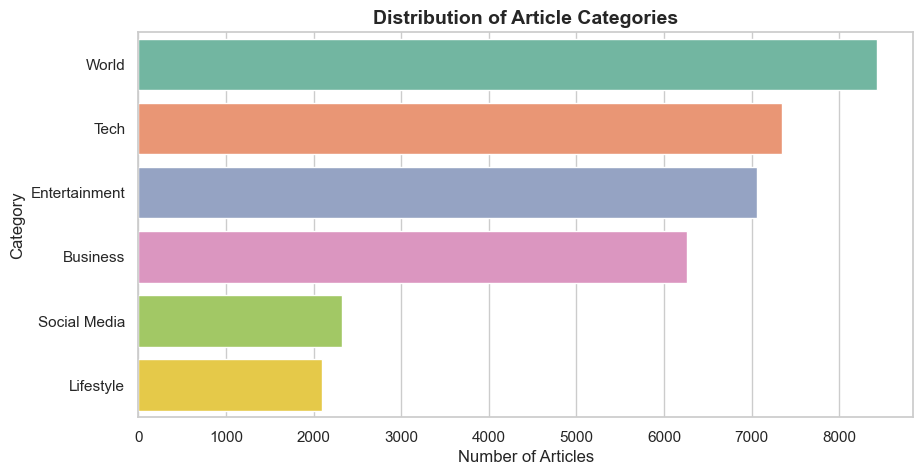

In [5]:
plt.figure(figsize=(10, 5))
sns.countplot(y=data['category'], order=data['category'].value_counts().index, palette='Set2')
plt.title('Distribution of Article Categories', fontweight='bold', fontsize=14)
plt.xlabel('Number of Articles')
plt.ylabel('Category')
plt.show()

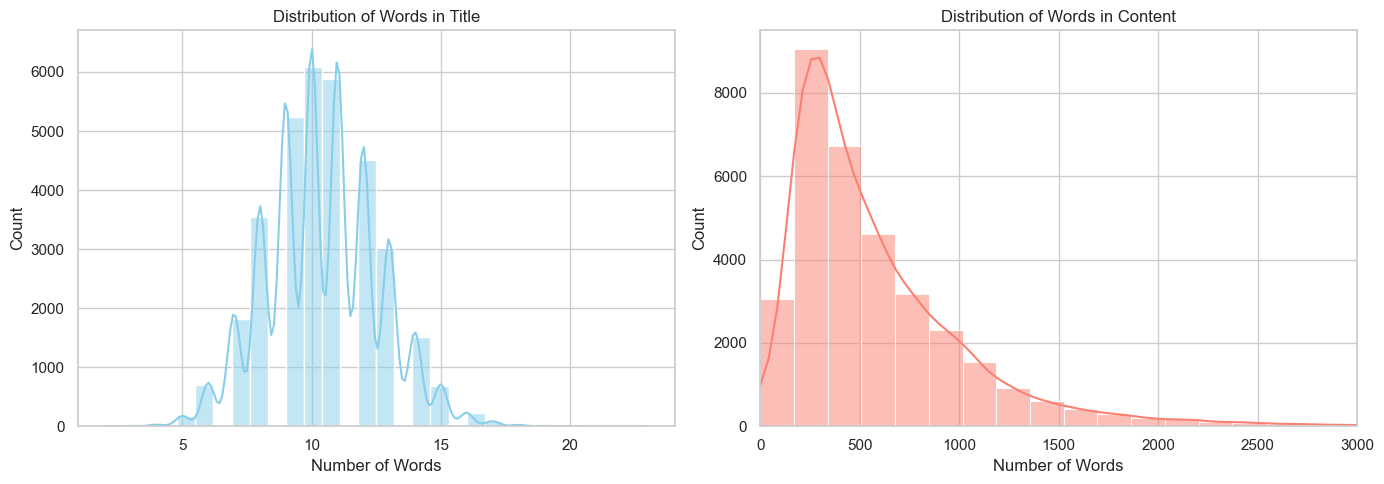

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data['n_tokens_title'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Words in Title')
axes[0].set_xlabel('Number of Words')

sns.histplot(data['n_tokens_content'], bins=50, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribution of Words in Content')
axes[1].set_xlim(0, 3000) # Capped view for readability
axes[1].set_xlabel('Number of Words')

plt.tight_layout()
plt.show()

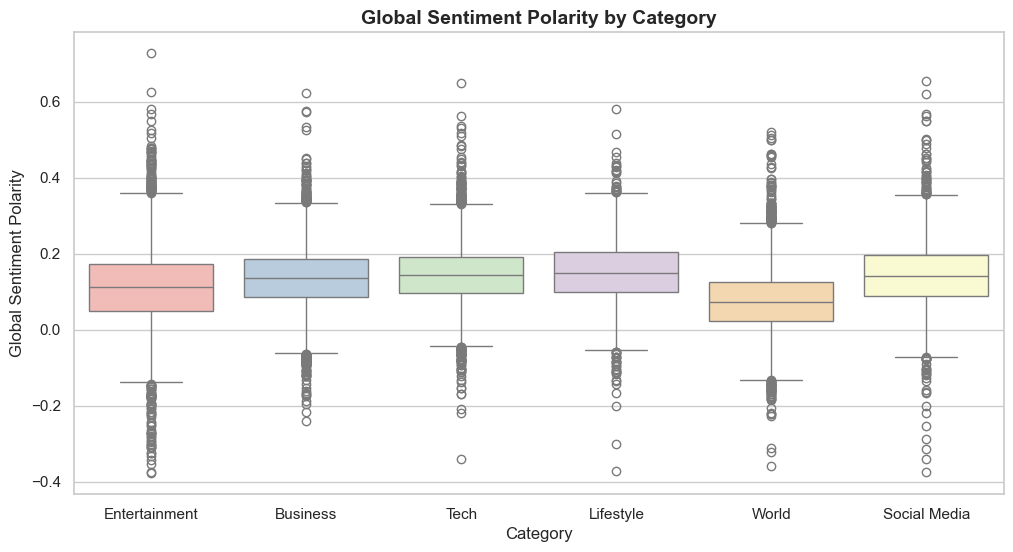

In [7]:
# Let's visualize how the Average Sentiment Polarity differs across categories

plt.figure(figsize=(12, 6))
sns.boxplot(x='category', y='global_sentiment_polarity', data=data, palette='Pastel1')
plt.title('Global Sentiment Polarity by Category', fontweight='bold', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Global Sentiment Polarity')
plt.show()

--- 
## 4. Feature Selection & Preprocessing

In [8]:
# Drop meta columns, identifiers, and encoded category columns
drop_cols = [
    'url', 'timedelta', 'shares', 'category',
    'data_channel_is_lifestyle', 'data_channel_is_entertainment',
    'data_channel_is_tech', 'data_channel_is_bus',
    'data_channel_is_world', 'data_channel_is_socmed'
]

features = [col for col in data.columns if col not in drop_cols]
X = data[features]
y = data['category']

print(f'Total features chosen for training: {len(features)}')

# Splitting the Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardizing Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Data split and standardized successfully! (✔️)')

Total features chosen for training: 52
Data split and standardized successfully! (✔️)


--- 
## 5. Model Training

In [9]:
print("Training Multiple Models... This will take just a few seconds.")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test_scaled))

# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_scaled))

# Fast Gradient Boosting
hgb = HistGradientBoostingClassifier(max_iter=150, random_state=42)
hgb.fit(X_train_scaled, y_train)
hgb_acc = accuracy_score(y_test, hgb.predict(X_test_scaled))

print("\n--- Training Complete ---")
print(f'Random Forest Accuracy:          {rf_acc*100:.2f}%')
print(f'Logistic Regression Accuracy:    {lr_acc*100:.2f}%')
print(f'Hist-Gradient Boosting Accuracy: {hgb_acc*100:.2f}%')

Training Multiple Models... This will take just a few seconds.


  File "C:\Users\S P THAROON\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\S P THAROON\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\S P THAROON\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\S P THAROON\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\S P THAROON\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1538, in _execute_child
    h


--- Training Complete ---
Random Forest Accuracy:          83.60%
Logistic Regression Accuracy:    78.68%
Hist-Gradient Boosting Accuracy: 88.02%


--- 
## 6. Model Evaluation Visualizations

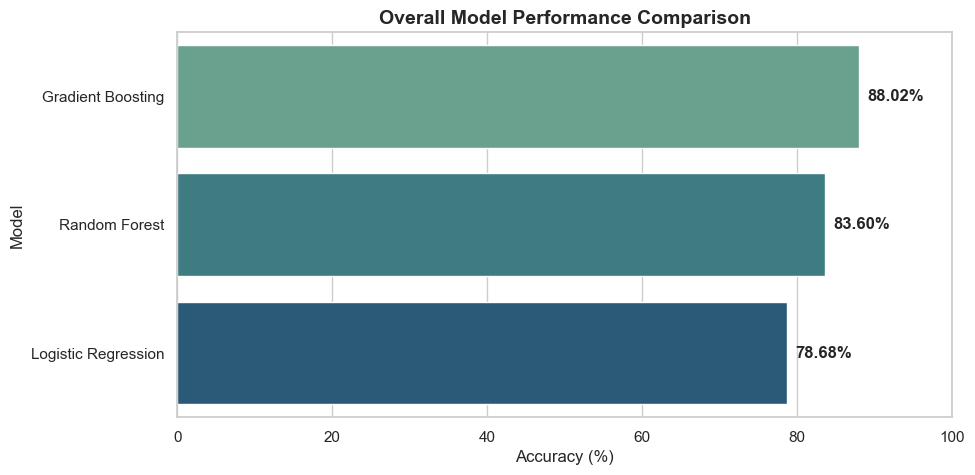

In [10]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'Gradient Boosting'],
    'Accuracy (%)': [rf_acc*100, lr_acc*100, hgb_acc*100]
}).sort_values('Accuracy (%)', ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Accuracy (%)', y='Model', data=results, palette='crest')
plt.title('Overall Model Performance Comparison', fontweight='bold', fontsize=14)
plt.xlim(0, 100)

for i, v in enumerate(results['Accuracy (%)']):
    ax.text(v + 1, i, f'{v:.2f}%', va='center', fontweight='bold')
    
plt.show()

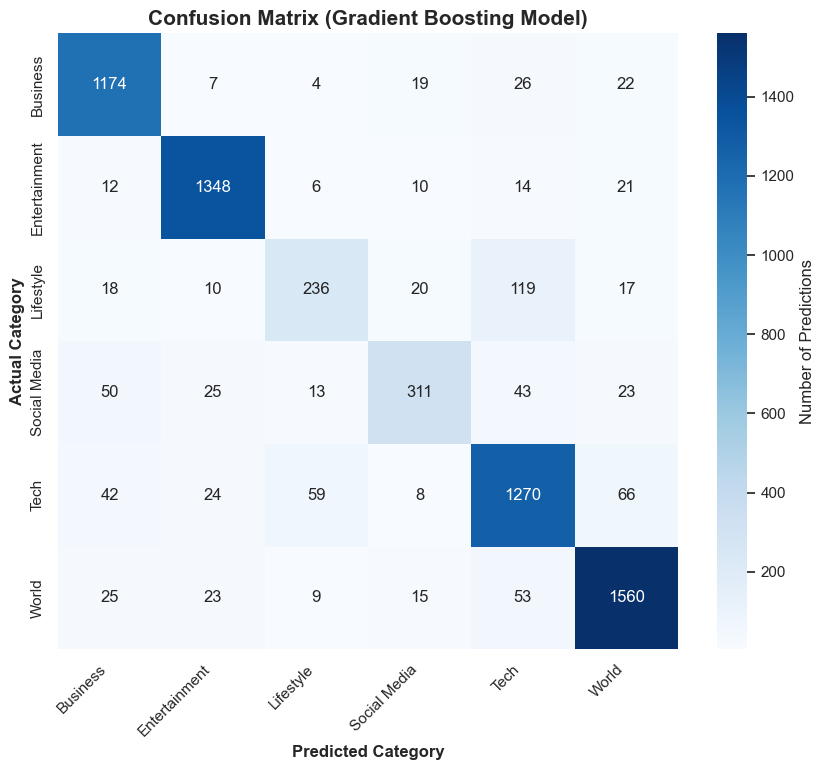

In [11]:
best_model = hgb
y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_model.classes_, yticklabels=best_model.classes_,
            cbar_kws={'label': 'Number of Predictions'})
plt.title('Confusion Matrix (Gradient Boosting Model)', fontweight='bold', fontsize=15)
plt.xlabel('Predicted Category', fontweight='bold')
plt.ylabel('Actual Category', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.show()

--- 
## 7. Feature Importance

Which fields does the Random Forest utilize most heavily when predicting the category?

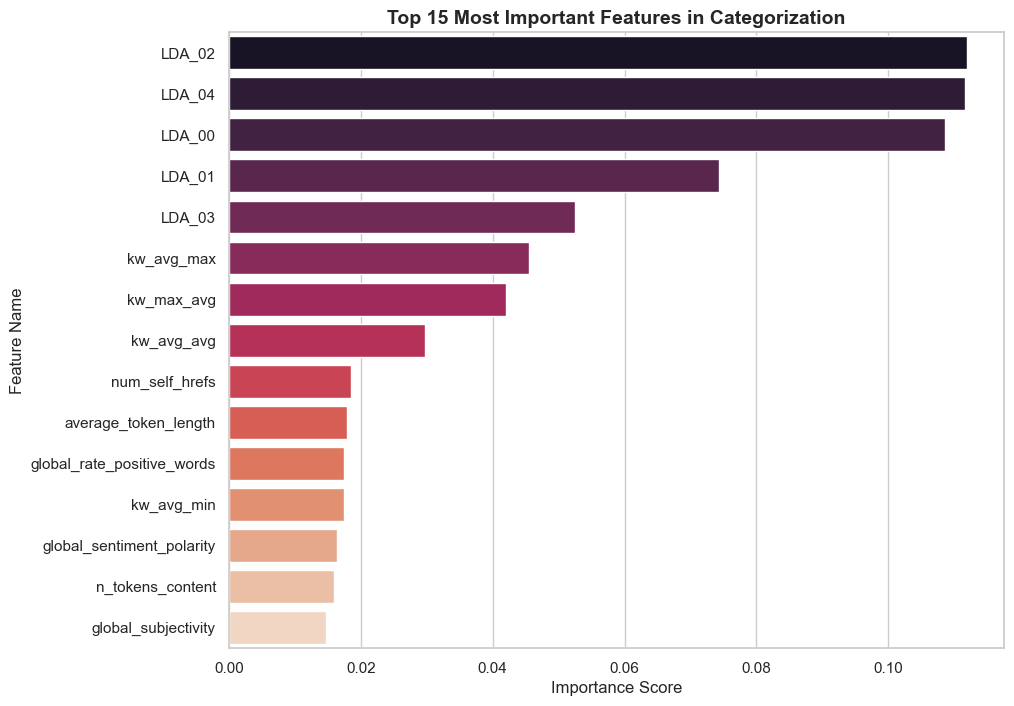

In [12]:
# Extract importances from Random Forest
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='rocket')
plt.title('Top 15 Most Important Features in Categorization', fontweight='bold', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()

### Sample Prediction Simulator

Testing a random single sample from the testing split against our absolute best model.

In [13]:
sample_idx = 10 
sample_data = X_test_scaled[sample_idx].reshape(1, -1)
actual_label = y_test.iloc[sample_idx]

predicted_label = best_model.predict(sample_data)[0]

print(f"\033[1mSample Selection Check\033[0m \n{'-'*30}")
print(f"Actual Category:    \033[92m{actual_label}\033[0m")
print(f"Predicted Category: \033[94m{predicted_label}\033[0m")
print("\n(If they match, our model accurately classified the article!)")

Sample Selection Check 
------------------------------
Actual Category:    Business
Predicted Category: Business

(If they match, our model accurately classified the article!)
